In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

In [3]:
dataset_path = "/content/drive/MyDrive/RetinaScanAI_edwin/dataset"

print(os.listdir(dataset_path))

['train.csv', 'train_images']


In [4]:
!pip install opencv-python-headless albumentations grad-cam -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 98.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision

from sklearn.model_selection import train_test_split

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
import pandas as pd

csv_path = "/content/drive/MyDrive/RetinaScanAI_edwin/dataset/train.csv"

df = pd.read_csv(csv_path)

df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


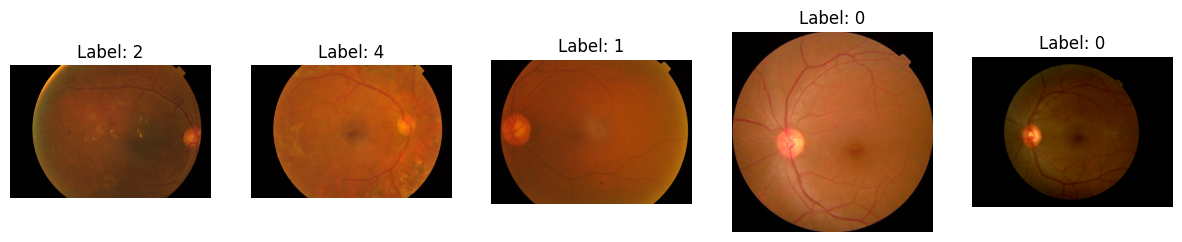

In [7]:
import cv2
import matplotlib.pyplot as plt
import os

image_folder= "/content/drive/MyDrive/RetinaScanAI_edwin/dataset/train_images"
plt.figure(figsize=(15,5))
for i in range(5):
    image_id = df.iloc[i]["id_code"]
    label = df.iloc[i]["diagnosis"]

    img = cv2.imread(os.path.join(image_folder, image_id + ".png"))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.show()

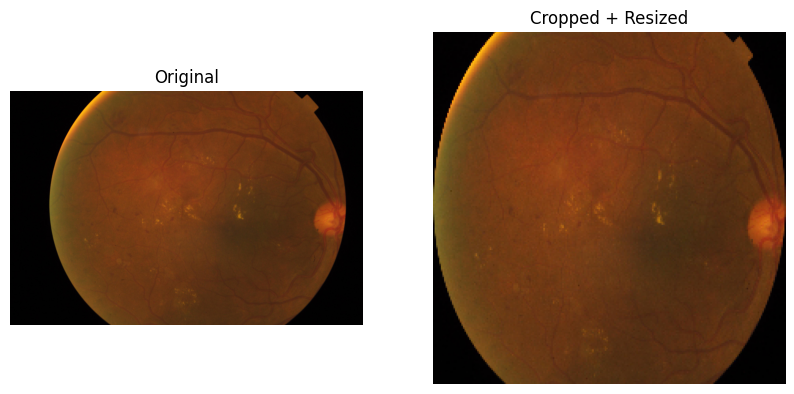

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to crop black borders
def crop_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    coords = cv2.findNonZero(thresh)

    x, y, w, h = cv2.boundingRect(coords)

    cropped = image[y:y+h, x:x+w]

    return cropped

# Load one sample image
sample_path = image_folder + "/" + df.iloc[0]["id_code"] + ".png"

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

cropped = crop_image(img)

resized = cv2.resize(cropped, (224, 224))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resized)
plt.title("Cropped + Resized")
plt.axis("off")

plt.show()

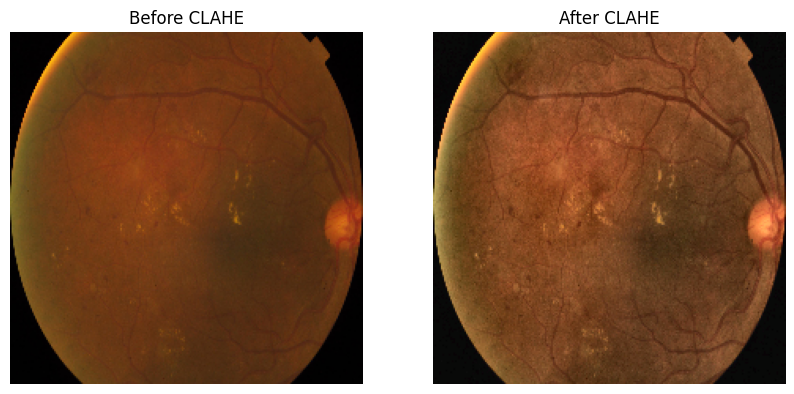

In [9]:
lab = cv2.cvtColor(resized, cv2.COLOR_RGB2LAB)

l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

l = clahe.apply(l)

enhanced = cv2.merge((l, a, b))

enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(resized)
plt.title("Before CLAHE")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced)
plt.title("After CLAHE")
plt.axis("off")

plt.show()

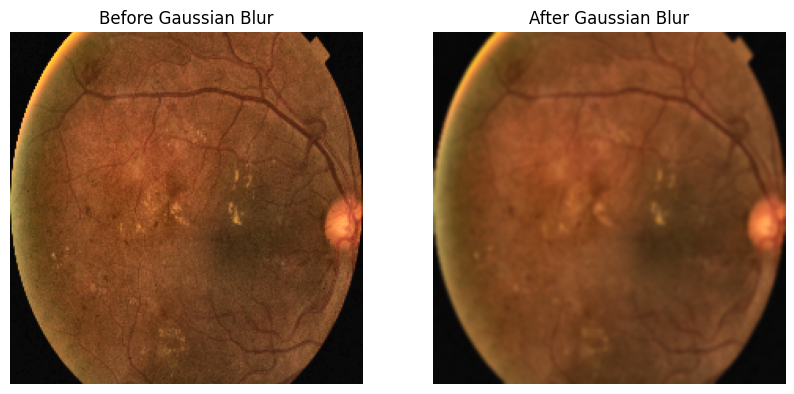

In [10]:
blurred = cv2.GaussianBlur(enhanced, (5,5), 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(enhanced)
plt.title("Before Gaussian Blur")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blurred)
plt.title("After Gaussian Blur")
plt.axis("off")

plt.show()

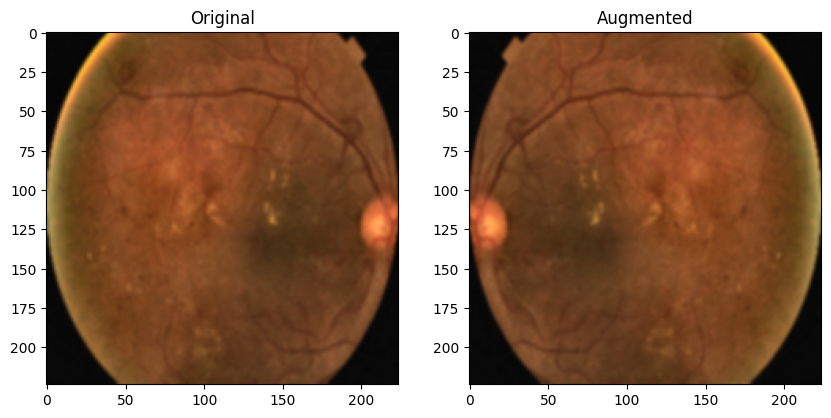

In [11]:
import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5)
])

augmented = transform(image=blurred)["image"]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(blurred)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(augmented)
plt.title("Augmented")

plt.show()

In [12]:
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet50
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [13]:
for param in model.parameters():
    param.requires_grad = False

In [14]:
model.fc = nn.Linear(model.fc.in_features, 5)

print(model.fc)

Linear(in_features=2048, out_features=5, bias=True)


In [15]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["diagnosis"]
)

print(f"Training Images: {len(train_df)}")
print(f"Validation Images: {len(val_df)}")

Training Images: 2929
Validation Images: 733


In [16]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [17]:
from torch.utils.data import Dataset
from PIL import Image
import os

class RetinaDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_name = self.df.loc[idx, "id_code"] + ".png"

        image_path = os.path.join(self.image_dir, image_name)

        image = Image.open(image_path).convert("RGB")

        label = int(self.df.loc[idx, "diagnosis"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [18]:
!cp -r "/content/drive/MyDrive/RetinaScanAI_edwin/dataset/train_images" /content/

In [19]:
image_dir = "/content/train_images"

train_dataset = RetinaDataset(
    train_df,
    image_dir,
    train_transform
)

val_dataset = RetinaDataset(
    val_df,
    image_dir,
    val_transform
)

In [20]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print(len(train_loader))

92


In [21]:
import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.0001
)

In [47]:
TRAIN_MODEL = False

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

if TRAIN_MODEL:

    num_epochs = 5

    best_val_loss = float("inf")

    for epoch in range(num_epochs):

        # Training
        model.train()

        train_loss = 0

        for batch_idx, (images, labels) in enumerate(train_loader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

            if (batch_idx + 1) % 20 == 0:
                print(f"Epoch {epoch+1}/{num_epochs} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()

        val_loss = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        print(f"\nEpoch {epoch+1} Completed")
        print(f"Training Loss : {avg_train_loss:.4f}")
        print(f"Validation Loss : {avg_val_loss:.4f}")

        # Save Best Model
        if avg_val_loss < best_val_loss:

            best_val_loss = avg_val_loss

            torch.save(
                model.state_dict(),
                "/content/drive/MyDrive/RetinaScanAI_edwin/best_model.pth"
            )

            print("Best model saved!\n")

else:
    print("Training skipped. Using the pretrained model.")

Training skipped. Using the pretrained model.


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

import numpy as np

In [23]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/RetinaScanAI_edwin/best_model.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [25]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [26]:
accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

qwk = cohen_kappa_score(
    all_labels,
    all_preds,
    weights="quadratic"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"Quadratic Weighted Kappa : {qwk:.4f}")

Accuracy : 0.7053
Precision : 0.5502
Recall : 0.7053
F1 Score : 0.6166
Quadratic Weighted Kappa : 0.6640


In [27]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/train_images/000c1434d8d7.png"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

rgb_img = image.astype(np.float32) / 255.0

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

input_tensor = transform(image).unsqueeze(0).to(device)

In [28]:
image_path = "/content/train_images/000c1434d8d7.png"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

rgb_img = image.astype(np.float32) / 255.0

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

input_tensor = transform(image).unsqueeze(0).to(device)

Saving fefded6bf135.png to fefded6bf135.png


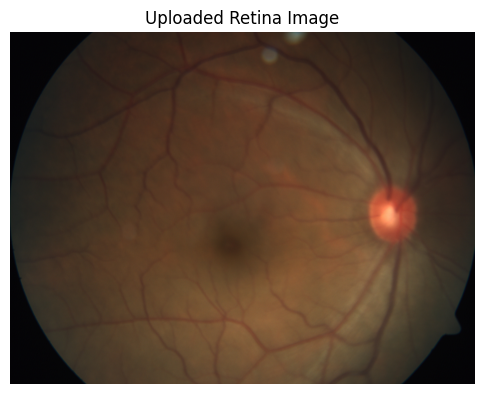

In [29]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Uploaded Retina Image")
plt.axis("off")
plt.show()

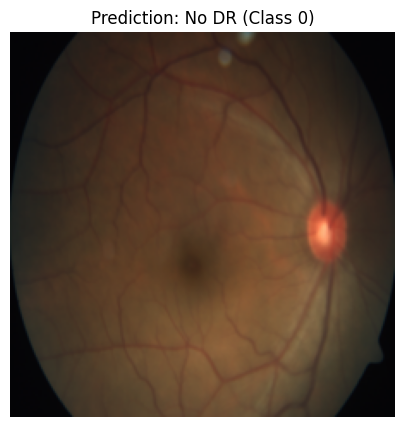

In [30]:
display_transform = transforms.Compose([
    transforms.Resize((224,224))
])

display_image = display_transform(image)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

input_tensor = transform(image).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(input_tensor)
    predicted_class = torch.argmax(output, dim=1).item()

class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR"
}

plt.figure(figsize=(5,5))
plt.imshow(display_image)
plt.title(f"Prediction: {class_names[predicted_class]} (Class {predicted_class})")
plt.axis("off")
plt.show()

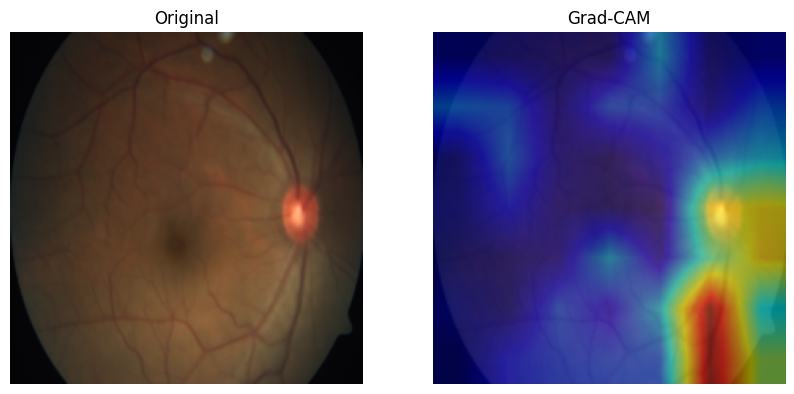

In [46]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

rgb_img = np.array(display_image).astype(np.float32) / 255.0

target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

model.eval()
model.zero_grad()

input_tensor = input_tensor.clone().detach().requires_grad_(True)

with torch.enable_grad():
    output = model(input_tensor)
    target_category = output.argmax(dim=1).item()
    targets = [ClassifierOutputTarget(target_category)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

grayscale_cam = cv2.resize(
    grayscale_cam,
    (rgb_img.shape[1], rgb_img.shape[0])
)

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()